# **DATA EXPLORATION TABULAR**

---

## **1. Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import missingno as msno

import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns

## **2. Load Raw Data**

Trong giai đoạn đầu của quá trình phân tích thống kê khám phá dữ liệu (EDA), nhóm tiến hành tải tập dữ liệu thô (raw data) *Adult Census Income* từ tệp CSV được lưu trữ trong cấu trúc thư mục dự án (`data/raw/`).

Khác với các bộ dữ liệu đã được làm sạch sẵn, dữ liệu điều tra dân số thực tế thường chứa các ký tự dị thường đại diện cho giá trị bị khuyết. Qua kiểm tra nhanh tệp nguồn, nhóm phát hiện các giá trị thiếu được mã hóa dưới dạng chuỗi `'?'`. Để đảm bảo các thuật toán thống kê phía sau hoạt động chính xác, nhóm sẽ tiến hành đọc dữ liệu và lập tức ép kiểu các giá trị `'?'` này về chuẩn `np.nan` của Pandas.

In [2]:
adult_path = "../data/raw/tabular/adult.csv"
df_adult = pd.read_csv(adult_path)
df_adult = df_adult.replace(regex=r'^\s*\?\s*$', value=np.nan)

Dữ liệu được đọc từ tệp `adult.csv` thành công và được khởi tạo dưới dạng cấu trúc dữ liệu bảng (tabular), lưu trữ trong biến DataFrame `df_adult`.

## **3. Basic Dataset Overview**

### **3.1 Dataset Dimensions**

Bước đầu tiên để nắm bắt quy mô của dữ liệu là kiểm tra chiều không gian (số lượng quan sát và số lượng đặc trưng/thuộc tính).

In [3]:
num_rows_train, num_cols_train = df_adult.shape
print(f"Number of rows: {num_rows_train}")
print(f"Number of columns: {num_cols_train}")

Number of rows: 32561
Number of columns: 15


Tập dữ liệu **Adult Census Income** có quy mô tầm trung nhưng vô cùng đậm đặc về mặt thông tin, bao gồm *32.561 quan sát* và *15 biến đặc trưng (thuộc tính)*.

### **3.2 Observational Unit**

Đơn vị quan sát cốt lõi của tập dữ liệu này được xác định như sau:

> **Một bản ghi tương ứng với một cá nhân (người trưởng thành) tham gia vào cuộc điều tra dân số năm 1994 tại Mỹ**.

**Đặc điểm cấu trúc dữ liệu:** Đây là bộ dữ liệu dạng bảng (Tabular Data) mang tính chất xã hội học - nhân khẩu học. Nó vẽ nên một bức tranh toàn diện về một con người thông qua các đặc trưng sinh học (tuổi, giới tính, chủng tộc), nền tảng xã hội (giáo dục, tình trạng hôn nhân) và tình trạng kinh tế (nghề nghiệp, số giờ làm việc, thu nhập).

### **3.3 Initial Data Glimpse**

Để có cái nhìn ban đầu về cấu trúc và định dạng của dataset, nhóm hiển thị 5 dòng đầu tiên, 5 dòng cuối cùng và thống kê kiểu dữ liệu tổng quát:

In [4]:
# Xem 5 dòng đầu tiên
display(df_adult.head())

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [5]:
# Xem 5 dòng cuối
display(df_adult.tail())

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32560,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


**Summary of Column Types**

In [6]:
dtype_summary = df_adult.dtypes.value_counts().reset_index()
dtype_summary.columns = ['Data Type', 'Count']
dtype_summary['Example Features'] = dtype_summary['Data Type'].apply(
    lambda t: [col for col in df_adult.columns if df_adult[col].dtype == t][:3]
)

print("Data Type Distribution:")
display(dtype_summary)

print("\nDetailed Feature Types:")
numerical_feats = df_adult.select_dtypes(include=['float64', 'int64']).columns
categorical_feats = df_adult.select_dtypes(include=['object']).columns

print(f" - Numerical Features ({len(numerical_feats)}): {list(numerical_feats)}")
print(f" - Categorical Features ({len(categorical_feats)}): {list(categorical_feats)}")

Data Type Distribution:


,Data Type,Count,Example Features
0,object,9,"[workclass, education, marital.status]"
1,int64,6,"[age, fnlwgt, education.num]"



Detailed Feature Types:
 - Numerical Features (6): ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
 - Categorical Features (9): ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country', 'income']


Kết quả phân tích cho thấy tập dữ liệu có sự phân bổ rất cân bằng giữa *6 biến số học (`int64`)* và *9 biến phân loại/chuỗi (`object`)*. Không có biến định danh (ID) vô nghĩa nào cần phải loại bỏ ngay từ đầu, cho thấy chất lượng các thuộc tính rất cao. Tuy nhiên, biến mục tiêu `income` hiện đang ở dạng chuỗi (`<=50K`, `>50K`), đòi hỏi phải thực hiện Label Encoding trong bước tiền xử lý để thuật toán học máy có thể tiếp nhận.

## **4. Data Semantics**

### **4.1 The meaning of each row**

Mỗi dòng đại diện cho "hồ sơ kinh tế - xã hội" của một cá nhân. Hệ thống đặc trưng được xây dựng để trả lời 3 nhóm câu hỏi cốt lõi:
1. **Người này là ai?** (Tuổi tác, giới tính, nguồn gốc, gia đình).
2. **Năng lực và vị thế xã hội của họ ra sao?** (Trình độ học vấn, loại hình công việc, vai trò nghề nghiệp).
3. **Mức độ tham gia lao động và tài sản?** (Số giờ làm việc, lợi nhuận/thua lỗ từ các khoản đầu tư).
4. **Nhãn thực tế (Ground truth):** Thu nhập hàng năm của người này từ 50.000 USD trở xuống (`<=50K`) hay vượt mức 50.000 USD (`>50K`).

**Tính chất:** Đây là bài toán *phân loại nhị phân (Binary Classification)*. Trong xã hội thực tế, số người có thu nhập cao luôn ít hơn số người có thu nhập trung bình/thấp, do đó nhóm dự báo tập dữ liệu này sẽ có hiện tượng *mất cân bằng lớp*.

### **4.2 The meaning of each column**

In [7]:
df_adult.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


Không gian đặc trưng gồm 15 biến được phân loại thành 4 nhóm ngữ nghĩa chính:

1. **Nhóm biến nhân khẩu học:**
   * `age`: Tuổi của cá nhân (biến số). *Yếu tố có độ tương quan mạnh với thu nhập do sự tích lũy kinh nghiệm.*
   * `sex`, `race`, `native.country`: Giới tính, chủng tộc và quốc gia gốc (biến phân loại). 
   * `marital.status`, `relationship`: Tình trạng hôn nhân và vai trò trong gia đình.

2. **Nhóm biến kinh tế - giáo dục:**
   * `education` và `education.num`: Trình độ học vấn. Hai biến này mang thông tin hoàn toàn trùng lặp (một dạng chữ, một dạng số thể hiện số năm đi học). 
   * `workclass`: Khu vực kinh tế đang làm việc (tư nhân, nhà nước, tự do...).
   * `occupation`: Chức danh nghề nghiệp cụ thể.
   * `hours.per.week`: Số giờ làm việc trung bình mỗi tuần (biến số).

3. **Nhóm biến tài chính & thống kê:**
   * `capital.gain` / `capital.loss`: Lợi nhuận/Thua lỗ ròng từ các khoản đầu tư tài sản ngoài lương (biến số). *Đặc điểm: Phần lớn dân số sẽ có giá trị = 0 ở 2 biến này, tạo ra phân phối lệch cực kỳ nghiêm trọng cần chuẩn hóa.*
   * `fnlwgt` (Final Weight): Trọng số thống kê do cục điều tra dân số gán. Những người có đặc điểm kinh tế - xã hội giống nhau sẽ có `fnlwgt` gần nhau. 

4. **Biến mục tiêu:**
   * `income`: Nhãn phân loại thu nhập (`<=50K` và `>50K`).

## **5. Distribution Analysis**

Theo yêu cầu tiền xử lý, do kích thước tập dữ liệu $n > 5000$, nhóm áp dụng *kiểm định D'Agostino-Pearson* để đánh giá mức độ phù hợp của dữ liệu với phân phối chuẩn thay vì Shapiro-Wilk.

### **5.1. Overview of D'Agostino-Pearson Omnibus Test**

Kiểm định D'Agostino-Pearson (thường được biết đến với tên gọi Omnibus $K^2$ test hay D'Agostino's $K^2$ test) là một kỹ thuật mạnh mẽ và thường được khuyến nghị để kiểm tra mức độ phù hợp của dữ liệu với phân phối chuẩn. 

Kiểm định này đo lường sự sai khác khỏi phân phối chuẩn bằng cách đánh giá đồng thời hình dáng của phân phối trên hai phương diện: tính bất đối xứng thông qua độ lệch (Skewness) và độ dày của phần đuôi thông qua độ nhọn (Kurtosis). Sau đó, nó tổng hợp những sai lệch này để tính toán ra một p-value duy nhất.

### **5.2. Hypothesis Formulation**

Tương tự các kiểm định tính chuẩn khác, giả thuyết được đặt ra là:
* $H_0$ (Giả thuyết không): Mẫu dữ liệu được rút ra từ một tổng thể có phân phối chuẩn.
* $H_1$ (Giả thuyết thay thế hay đối thuyết): Mẫu dữ liệu không tuân theo phân phối chuẩn.

### **5.3 Core Mathematical Algorithms**

Thống kê Omnibus $K^2$ được cấu thành thông qua 4 bước cơ bản:

**Bước 1: Tính Skewness và Kurtosis mẫu**

Cho một mẫu gồm $n$ quan sát $x_i$, trung bình mẫu $\bar{x}$, và các moment trung tâm mẫu $m_j = \frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^j$.
* Độ lệch (Skewness): $g_1 = \frac{m_3}{m_2^{3/2}}$
* Độ nhọn dư thừa (Excess Kurtosis): $g_2 = \frac{m_4}{m_2^2} - 3$

**Bước 2: Biến đổi Skewness thành biến chuẩn hóa $Z_1$**

Sử dụng phép biến đổi hàm sinh ngược để tạo ra giá trị $Z_1$ phân phối xấp xỉ chuẩn tắc:
$$Z_1(g_1) = \delta \operatorname{asinh} \left( \frac{g_1}{\alpha \sqrt{\mu_2(g_1)}} \right)$$
*(Trong đó $\mu_2(g_1)$ là phương sai lý thuyết của độ lệch; $\delta$, $\alpha$ là các hằng số phụ thuộc vào độ nhọn lý thuyết).*

**Bước 3: Biến đổi Kurtosis thành biến chuẩn hóa $Z_2$**

Áp dụng phép biến đổi Anscombe & Glynn để đưa độ nhọn $g_2$ về biến $Z_2$ có phân phối xấp xỉ chuẩn tắc (với $n \ge 20$):
$$Z_2(g_2) = \sqrt{\frac{9A}{2}} \left[ 1 - \frac{2}{9A} - \left( \frac{1 - 2/A}{1 + \frac{g_2 - \mu_1(g_2)}{\sqrt{\mu_2(g_2)}} \sqrt{\frac{2}{A-4}}} \right)^{1/3} \right]$$

**Bước 4: Tính thống kê Omnibus $K^2$**

Thống kê kiểm định tổng quát được kết hợp bằng tổng bình phương của hai giá trị đã được chuẩn hóa:
$$K^2 = Z_1(g_1)^2 + Z_2(g_2)^2$$
Nếu giả thuyết $H_0$ đúng, thống kê $K^2$ xấp xỉ tuân theo phân phối Chi-bình phương ($\chi^2$) với 2 bậc tự do.

### **5.4 Decision Rule & Limitations**

* **Tiêu chí:** Nếu p-value $\le 0.05$, ta bác bỏ $H_0$ (dữ liệu không chuẩn). Nếu p-value $> 0.05$, không đủ bằng chứng bác bỏ $H_0$ (dữ liệu phân phối chuẩn).
* **Blind spot:** Kiểm định này chỉ phân tích sự khác biệt qua Skewness và Kurtosis. Nếu một phân phối bất thường nhưng tình cờ có Skewness = 0 và Excess Kurtosis = 0, thuật toán sẽ bỏ sót (Type II error).

### **5.5 Implementation & Distribution Classification**

Nhóm tiến hành trích xuất toàn bộ danh sách các biến định lượng (numerical features) của bộ Adult Census và chạy kiểm định `scipy.stats.normaltest` (cài đặt chuẩn của D'Agostino-Pearson). 

In [8]:
# Select numerical features
numeric_columns = df_adult.select_dtypes(include=['float64', 'int64']).columns
features_to_evaluate = numeric_columns.tolist()

# Initialize storage
alpha = 0.05
normality_results = []

# Apply D'Agostino-Pearson normality test
for feature in features_to_evaluate:
    data = df_adult[feature].dropna()
    
    # Perform normality test
    k2_statistic, p_value = stats.normaltest(data)
    
    # Determine distribution type
    is_gaussian = p_value > alpha
    distribution_label = "Gaussian" if is_gaussian else "Non-Gaussian"
    
    # Compute skewness
    skewness_value = data.skew()
    
    # Store results
    normality_results.append({
        "Feature": feature,
        "K2 Statistic": round(k2_statistic, 3),
        "P-value": p_value,
        "Skewness": round(skewness_value, 3),
        "Distribution": distribution_label
    })

df_normality = pd.DataFrame(normality_results)
display(df_normality)

,Feature,K2 Statistic,P-value,Skewness,Distribution
0,age,1526.011,0.000000e+00,0.559,Non-Gaussian
1,fnlwgt,10662.514,0.000000e+00,1.447,Non-Gaussian
2,education.num,817.164,3.589720e-178,-0.312,Non-Gaussian
3,capital.gain,55096.550,0.000000e+00,11.954,Non-Gaussian
4,capital.loss,29331.400,0.000000e+00,4.595,Non-Gaussian
5,hours.per.week,2508.918,0.000000e+00,0.228,Non-Gaussian


### **5.6 Scaling Strategy Proposal**

#### Distributional Characteristics

Dựa trên kết quả định lượng, tất cả các thuộc tính số đều có P-value xấp xỉ $0$ ($p < \alpha = 0.05$). Do đó, ta *bác bỏ giả thuyết không ($H_0$)*, kết luận rằng *không có thuộc tính nào trong tập dữ liệu tuân theo phân phối Gaussian (phân phối chuẩn).*

Bên cạnh đó, một số thuộc tính thể hiện độ lệch (skewness) đáng kể:
* **Độ lệch phải cực lớn:** `capital.gain` ($11.954$) và `capital.loss` ($4.595$). Phân phối có phần đuôi bên phải kéo rất dài. Điều này phản ánh thực tế cấu trúc tài chính: Đại đa số người dân không có lãi/lỗ từ đầu tư vốn (giá trị bằng 0), chỉ một nhóm cực nhỏ giới tinh hoa tài chính sở hữu các giá trị đột biến (ngoại lai).
* **Độ lệch phải trung bình/nhẹ:** `fnlwgt` ($1.447$), `age` ($0.559$) và `hours.per.week` ($0.228$). Độ tuổi và thời gian làm việc tập trung chủ yếu ở tầng lớp thanh niên/trung niên và mốc tiêu chuẩn 40 giờ/tuần, sau đó giảm dần.
* **Độ lệch trái:** `education.num` ($-0.312$). Đây là biến duy nhất lệch trái, cho thấy phần lớn người tham gia khảo sát đã hoàn thành các bậc giáo dục cao (trung học phổ thông, đại học trở lên), số người có số năm đi học thấp là thiểu số.

#### Implications for Feature Scaling

Do toàn bộ các biến đều không tuân theo phân phối chuẩn, việc áp dụng chuẩn hóa Z-score (StandardScaler) là không phù hợp, vì phương pháp này:

* Giả định dữ liệu gần phân phối chuẩn
* Nhạy cảm với các giá trị ngoại lai

Vì vậy, cần sử dụng các phương pháp chuẩn hóa có khả năng chống chịu ngoại lai và không phụ thuộc phân phối.

#### Recommended Scaling Strategy

Chiến lược chuẩn hóa được đề xuất theo từng nhóm đặc trưng như sau:

* **Đối với nhóm biến tài chính (`capital.gain`, `capital.loss`):** Do bị nhiễu nặng bởi dữ liệu lấp đầy số 0 và ngoại lai cực đoan, nhóm đề xuất sử dụng *RobustScaler* (Sử dụng Median và phân vị IQR để kháng ngoại lai) hoặc sử dụng phép biến đổi logarit $log(1+x)$ (Log1p Transformation) trước khi chuẩn hóa để "kéo" phần đuôi dài về gần phân phối chuẩn hơn.
* **Đối với nhóm biến nhân khẩu học (`age`, `education.num`, `hours.per.week`):**
  Đây là các biến có giới hạn biên độ vật lý rõ ràng (tuổi từ 17-90, số năm đi học từ 1-16, giờ làm việc từ 1-99). Nhóm đề xuất sử dụng *MinMaxScaler* để đưa toàn bộ về không gian $[0, 1]$, giúp bảo toàn cấu trúc phân phối gốc và khoảng cách tương đối giữa các nhóm người mà không làm mất đi tính biểu đạt của dữ liệu.
* **Đối với biến trọng số (`fnlwgt`):**
  Biến này có độ phân tán lớn và ít mang giá trị logic trong việc dự báo thu nhập cá nhân. Nhóm sẽ cân nhắc loại bỏ thuộc tính này ở bước trích chọn đặc trưng nếu kết quả phân tích Random Forest Feature Importance cho thấy nó không đóng góp vào mô hình.

## **6. Multivariate Correlation & Multicollinearity Analysis**

Sau khi phân tích phân phối đơn biến, bước tiếp theo là đánh giá mối quan hệ tương quan đa biến (Multivariate Correlation) giữa các đặc trưng định lượng. Mục tiêu cốt lõi của phần này là phát hiện hiện tượng đa cộng tuyến (Multicollinearity) - tình trạng các biến độc lập tương quan quá mạnh với nhau, làm mất đi tính ổn định của các mô hình tuyến tính ở giai đoạn sau.

### **6.1 Theoretical Foundation: Correlation Metrics**

Để có góc nhìn toàn diện, nhóm kết hợp biểu đồ nhiệt (Heatmap) với hai phương pháp đo lường tương quan thống kê phổ biến nhất: Pearson và Spearman.

**1. Tương quan Pearson (Pearson's Correlation Coefficient - $r$)**
* **Ý nghĩa:** Đo lường độ mạnh và hướng của mối quan hệ tuyến tính giữa hai biến định lượng. 
* **Công thức:** Được tính bằng hiệp phương sai chia cho tích độ lệch chuẩn của hai biến:
$$r = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^n (x_i - \bar{x})^2 \sum_{i=1}^n (y_i - \bar{y})^2}} = \frac{Cov(x, y)}{\sigma_x \sigma_y}$$
* **Hạn chế:** Rất nhạy cảm với các giá trị ngoại lai (outliers) và chỉ nắm bắt được quan hệ tuyến tính.

**2. Tương quan Spearman (Spearman's Rank Correlation Coefficient - $\rho$)**
* **Ý nghĩa:** Là phương pháp phi tham số đo lường mối quan hệ đơn điệu. Phương pháp này đánh giá mức độ tương quan dựa trên thứ hạng (rank) của các giá trị dữ liệu thay vì dùng giá trị thực tế.
* **Ưu điểm:** Do sử dụng thứ hạng, Spearman kháng lại ngoại lai cực kỳ tốt, rất phù hợp cho tập dữ liệu chứa biến có phân phối bị lệch nghiêm trọng.
* **Công thức:** Khi không có các thứ hạng trùng lặp, công thức được đơn giản hóa thành:
$$\rho = 1 - \frac{6 \sum d_i^2}{n(n^2 - 1)}$$
*(Trong đó: $d_i$ là sự chênh lệch giữa thứ hạng của hai biến đối với cùng một cặp quan sát $i$).*

**3. Tiêu chí phát hiện đa cộng tuyến (Multicollinearity Threshold)**
Nhóm thiết lập ngưỡng phát hiện đa cộng tuyến mạnh là $|r| > 0.9$. Khi vượt quá ngưỡng này, hai biến mang lượng thông tin gần như trùng lặp, gây ra hiện tượng phình to phương sai trong các mô hình học máy.

### **6.2 Bivariate Analysis & Heatmap Visualization**

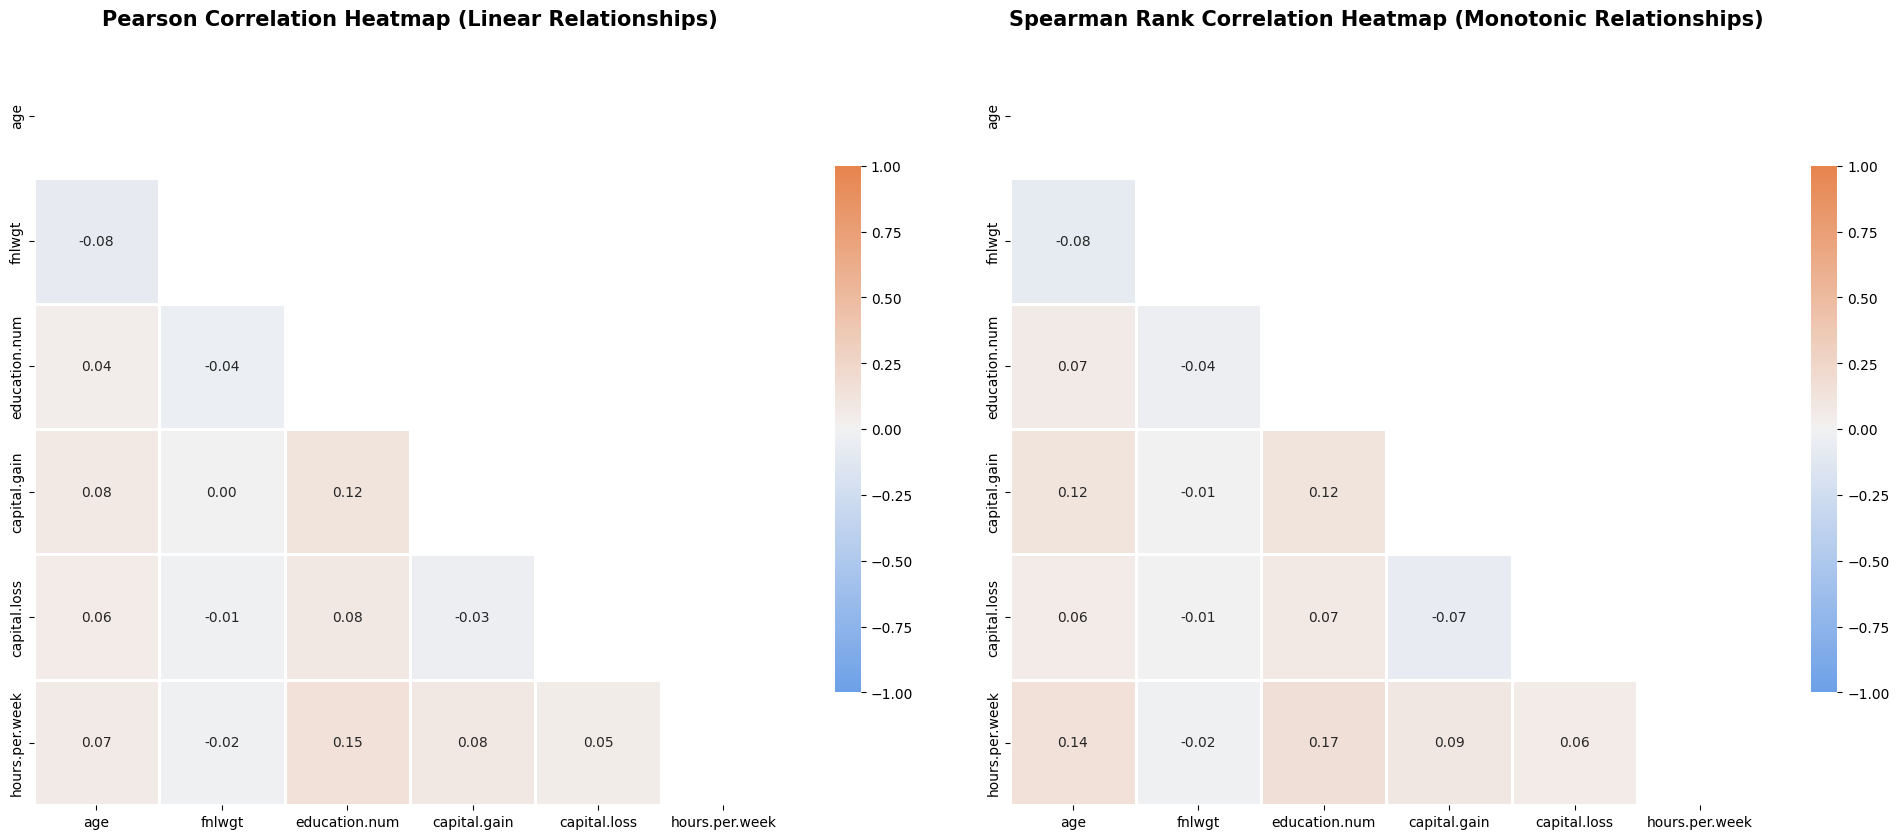

In [9]:
# Select numerical features for correlation analysis
numerical_features = ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
df_corr = df_adult[numerical_features]

# Compute correlation matrices
corr_pearson = df_corr.corr(method='pearson')
corr_spearman = df_corr.corr(method='spearman')

# Create upper-triangle mask (avoid duplicate information)
mask = np.triu(np.ones_like(corr_pearson, dtype=bool))

cmap = sns.diverging_palette(250, 30, l=65, center="light", as_cmap=True)
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Heatmap Pearson
sns.heatmap(corr_pearson, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
            square=True, linewidths=1, linecolor='white', cbar_kws={"shrink": 0.7}, 
            annot=True, fmt=".2f", ax=axes[0])
axes[0].set_title('Pearson Correlation Heatmap (Linear Relationships)', fontsize=15, fontweight='bold', pad=20)

# Heatmap Spearman
sns.heatmap(corr_spearman, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
            square=True, linewidths=1, linecolor='white', cbar_kws={"shrink": 0.7}, 
            annot=True, fmt=".2f", ax=axes[1])
axes[1].set_title('Spearman Rank Correlation Heatmap (Monotonic Relationships)', fontsize=15, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

### **6.3 Multicollinearity Detection & Critical Analysis**

Phân tích ma trận tương quan dựa trên kết quả chạy thực tế bằng cả hai phương pháp Pearson và Spearman, nhóm rút ra các nhận xét  sau:

1. **Không tồn tại đa cộng tuyến:**
   * Khác với các tập dữ liệu chuỗi thời gian hoặc tọa độ vật lý, trong bộ Adult Census Income, *không có bất kỳ cặp thuộc tính nào vi phạm ngưỡng đa cộng tuyến mạnh ($|r| \ge 0.9$ hoặc thậm chí $|r| \ge 0.5$)*.
   * Hệ số tương quan cao nhất ghi nhận được chỉ dừng ở mức cực kỳ thấp: giữa `education.num` và `hours.per.week` (Pearson $r = 0.15$, Spearman $\rho = 0.17$). Điều này chứng tỏ 6 biến số học cung cấp lượng thông tin hoàn toàn độc lập.

2. **Mối quan hệ phi tuyến, sự khác biệt giữa Pearson và Spearman:**
   * *Sự chênh lệch tại cặp `age` (Tuổi) và `hours.per.week` (Giờ làm việc):* Tương quan tuyến tính Pearson rất yếu ($r = 0.07$), nhưng tương quan Spearman lại tăng gấp đôi ($\rho = 0.14$). Sự gia tăng này ngầm chỉ ra một mối quan hệ phi tuyến: Thời gian làm việc tăng dần theo độ tuổi (từ lúc trẻ đến trung niên), nhưng sau đó sẽ tạo đỉnh và sụt giảm mạnh khi bước vào tuổi hưu trí, khiến đường thẳng Pearson không thể nắm bắt được.
   * *Sự chênh lệch tại cặp `age` và `capital.gain`:* Tương tự, hệ số Spearman ($\rho = 0.12$) lớn hơn Pearson ($r = 0.08$), do Spearman ít bị nhiễu bởi các "đại gia" ngoại lai có thu nhập đầu tư khổng lồ, phản ánh đúng hơn xu hướng: người càng lớn tuổi thì xác suất có tích lũy tư bản càng cao.
   * Biến `fnlwgt` (Trọng số dân số) ghi nhận tương quan âm nhẹ với `age` ($r = -0.08, \rho = -0.08$) và gần như độc lập ($0.00$) với các biến kinh tế khác, cho thấy nó mang ý nghĩa về cấu trúc lấy mẫu của Cục điều tra dân số hơn là yếu tố quyết định thu nhập.

### **6.4 Proposed Treatments for Multicollinearity**

Việc phát hiện *không có* đa cộng tuyến là một tín hiệu cực kỳ tích cực cho thấy chất lượng nguyên bản của tập dữ liệu.

* **Bảo toàn không gian đặc trưng:** Vì không có cặp biến nào vi phạm ngưỡng $|r| \ge 0.9$, nếu đưa trực tiếp các biến này vào các thuật toán hồi quy tuyến tính (như Logistic Regression), hệ thống sẽ hoạt động ổn định mà không lo ngại hiện tượng phình to phương sai (Variance Inflation Factor - VIF ở mức an toàn).
* **Quyết định tiền xử lý:** Nhóm đề xuất giữ nguyên toàn bộ 6 biến số định lượng này mà không cần phải thực hiện các kỹ thuật loại bỏ hay gộp biến giảm chiều (PCA) để khắc phục đa cộng tuyến. 
* *Lưu ý phụ:* Mặc dù không loại bỏ vì đa cộng tuyến, nhưng thuộc tính `fnlwgt` có thể được xem xét loại bỏ ở bước trích chọn đặc trưng phía sau do nó không mang nhiều giá trị logic trong việc phân loại mức thu nhập cá nhân.

## **7. Missing Value Analysis & Mechanisms** 

### **7.1 Classification of Missing Data Mechanisms**

Trong thống kê, cơ chế khuyết dữ liệu được phân thành 3 loại độc quyền lẫn nhau dựa trên xác suất xảy ra:

**1. Missing Completely At Random (MCAR - Khuyết hoàn toàn ngẫu nhiên):**
* Dữ liệu được coi là MCAR nếu xác suất bị khuyết hoàn toàn độc lập với cả dữ liệu đã quan sát được và dữ liệu bị ẩn. Dưới cơ chế này, phần dữ liệu còn lại có thể được xem là một mẫu ngẫu nhiên đại diện cho toàn bộ tập dữ liệu gốc.
* **Định nghĩa toán học:** Gọi $R$ (hoặc $M$) là biến chỉ báo khuyết, $Y_{obs}$ là dữ liệu quan sát được, $Y_{miss}$ là dữ liệu bị khuyết. Giả định MCAR được viết là: $P(R|Y_{obs}, Y_{miss}, X) = P(R)$.

**2. Missing At Random (MAR - Khuyết ngẫu nhiên):**
* Dữ liệu là MAR nếu xác suất bị khuyết chỉ phụ thuộc vào các biến đã quan sát được, nhưng hoàn toàn không phụ thuộc vào chính giá trị của phần dữ liệu bị khuyết. Tên gọi này khá dễ gây nhầm lẫn; thực chất nó mang ý nghĩa "khuyết ngẫu nhiên có điều kiện" dựa trên các biến đã biết.
* **Định nghĩa toán học:** $P(R|Y_{obs}, Y_{miss}, X) = P(R|Y_{obs}, X)$.

**3. Missing Not At Random (MNAR - Khuyết không ngẫu nhiên):**
* Dữ liệu là MNAR nếu xác suất khuyết phụ thuộc vào chính các giá trị bị khuyết, ngay cả khi đã kiểm soát các biến quan sát được. Đây là trường hợp tồi tệ nhất, vì bản thân sự "thiếu vắng" mang một thông tin ẩn (ví dụ: người thu nhập quá thấp thường bỏ trống câu hỏi về lương).
* **Định nghĩa toán học:** $P(R|Y_{obs}, Y_{miss}, X)$ phụ thuộc trực tiếp vào $Y_{miss}$.

### **7.2 Theoretical Foundation: Little's MCAR Test**

Để đánh giá chính thức giả thuyết MCAR một cách định lượng, Roderick J. A. Little (1988) đã đề xuất một kiểm định thống kê đa biến rất nổi tiếng.

**1. Nền tảng lý thuyết và giả thuyết:**

Cốt lõi của kiểm định này là so sánh trung bình của các biến quan sát được trên từng mẫu dữ liệu khuyết với giá trị trung bình kỳ vọng của tổng thể (được ước lượng qua thuật toán Expectation-Maximization - EM). 
* **Giả thuyết không ($H_0$):** Dữ liệu là MCAR. Trung bình của các biến quan sát được là đồng nhất trên mọi mẫu khuyết.
* **Giả thuyết thay thế ($H_1$):** Dữ liệu không phải là MCAR. (Lưu ý: Bác bỏ $H_0$ không đồng nghĩa với việc khẳng định đó là MAR hay MNAR).

**2. Công thức thống kê:**

Thống kê $d^2$ được tính bằng tổng bình phương khoảng cách giữa trung bình mẫu phụ và trung bình kỳ vọng, được gia quyền bởi ma trận hiệp phương sai:
$$d^2 = \sum_{j=1}^J n_j (y_{oj} - \hat{\mu}_{oj})^T \tilde{\Sigma}_{oj}^{-1} (y_{oj} - \hat{\mu}_{oj})$$
*(Trong đó: $J$ là số mẫu khuyết, $n_j$ là số quan sát của mẫu $j$, $\hat{\mu}_{oj}$ là trung bình ước lượng MLE, và $\tilde{\Sigma}_{oj}$ là ma trận hiệp phương sai con).*

Dưới giả thuyết $H_0$, thống kê $d^2$ tuân theo phân phối Chi-bình phương ($\chi^2$) với số bậc tự do $df = \sum_{j=1}^J p_j - p$.

**3. Hạn chế của kiểm định:**

* Phụ thuộc rất mạnh vào giả định phân phối chuẩn đa biến.
* Có thể mắc sai lầm loại II (Power thấp) nếu kích thước mẫu nhỏ hoặc số biến vi phạm MCAR quá ít.

### **7.3 Initial Missing Data Assessment**

Nhóm tiến hành viết hàm tổng quát `compute_missing_table` để quét toàn bộ không gian đặc trưng và thống kê tỷ lệ khuyết dữ liệu ban đầu.

In [10]:
def compute_missing_table(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute missing value statistics for each feature in the DataFrame.
    Returns a summary table sorted by missing percentage.
    """
    num_rows = df.shape[0]
    summary = []
    for col_name in df.columns:
        col = df[col_name]
        missing_count = col.isna().sum()
        if col.dtype == "object" or col.dtype.name == "category":
            missing_count += (col.astype(str).str.strip() == "").sum()
        missing_percent = (missing_count / num_rows) * 100
        summary.append([col_name, missing_count, missing_percent])
    missing_df = pd.DataFrame(summary, columns=["Feature", "Missing Count", "Missing %"])
    missing_df = missing_df.sort_values("Missing %", ascending=False).reset_index(drop=True)
    return missing_df

In [11]:
missing_df = compute_missing_table(df_adult)
total_cells = df_adult.size
total_missing = missing_df["Missing Count"].sum()
overall_missing_rate = (total_missing / total_cells) * 100

print("Dataset Missing Overview:")
print(f"- Total Missing Values    : {total_missing:,.0f}")
print(f"- Overall Missing Rate    : {overall_missing_rate:.2f}%")
print(f"- Columns With Missing    : {missing_df[missing_df['Missing Count'] > 0].shape[0]} / {df_adult.shape[1]}\n")

print("Detailed Missingness by Feature (Descending):")
display(
    missing_df.style
        .format({"Missing %": "{:.2f}%"})
        .bar(subset=["Missing %"], color="#FF6B6B", vmin=0, vmax=100)
        .background_gradient(subset=["Missing Count"], cmap="Reds", vmin=0)
)

Dataset Missing Overview:
- Total Missing Values    : 4,262
- Overall Missing Rate    : 0.87%
- Columns With Missing    : 3 / 15

Detailed Missingness by Feature (Descending):


,Feature,Missing Count,Missing %
0,occupation,1843,5.66%
1,workclass,1836,5.64%
2,native.country,583,1.79%
3,age,0,0.00%
4,fnlwgt,0,0.00%
5,education,0,0.00%
6,education.num,0,0.00%
7,marital.status,0,0.00%
8,relationship,0,0.00%
9,race,0,0.00%


**Nhận xét:** Kết quả thống kê cho thấy bộ dữ liệu tồn tại giá trị khuyết tự nhiên ở 3 thuộc tính phân loại (Categorical): `occupation` (5.66%), `workclass` (5.64%), và `native.country` (1.79%). Sự khuyết dữ liệu ở đây mang tính xã hội học (người tham gia khảo sát từ chối trả lời hoặc không thuộc lực lượng lao động).

### **7.4 Missingno Visualizations**

Nhóm sử dụng thư viện `missingno` để trực quan hóa cấu trúc dữ liệu khuyết dựa trên các nguyên tắc thiết kế sau:
* **Hiển thị mật độ:** Ma trận Nullity Matrix cung cấp cái nhìn tổng quan. Vùng màu xanh dương đại diện cho dữ liệu hoàn chỉnh, trong khi các giá trị khuyết (NaN) hiện lên dưới dạng các vạch ngang màu trắng.
* **Nhận diện mẫu:** Ma trận cho phép quan sát ngay lập tức sự phân bố của dữ liệu khuyết trên toàn bộ tập hợp. Kỹ thuật này giúp nhóm phát hiện xem lỗi là cục bộ, phân tán ngẫu nhiên, hay tuân theo một quy luật hệ thống đặc thù nào đó.
* **Tùy biến hiển thị:** Nhóm chủ động tắt đường xu hướng (Sparkline) để giảm nhiễu thị giác, tập trung sự chú ý của người đọc vào sự tương quan của các vạch trắng giữa các cột.

<Figure size 1000x500 with 0 Axes>

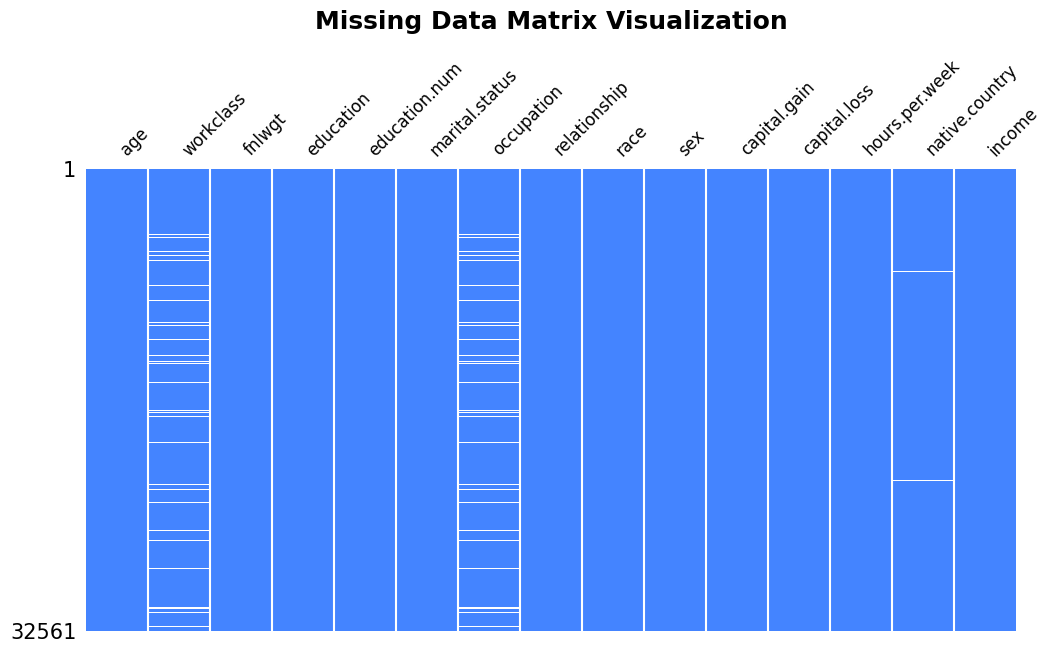

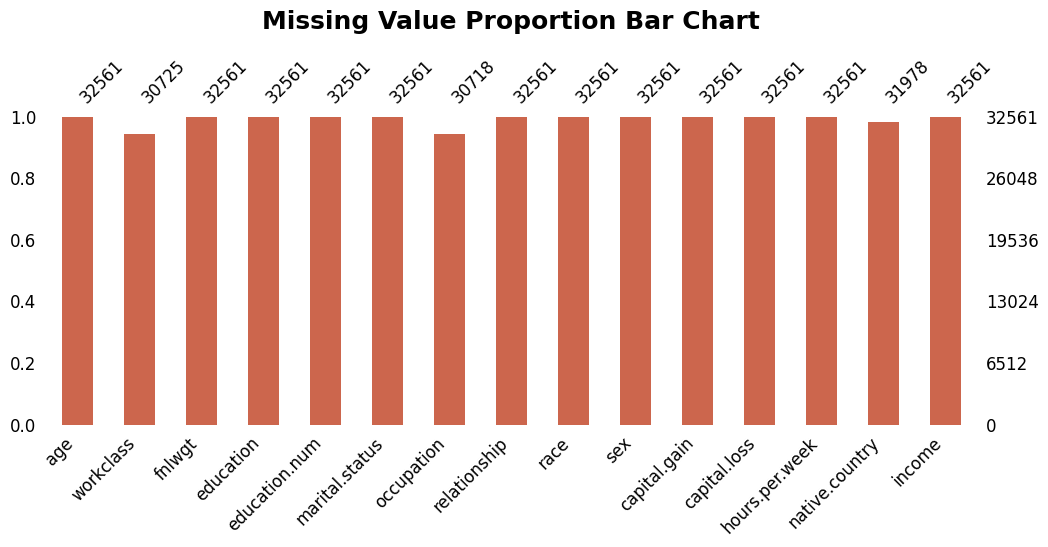

In [12]:
# cols_to_visualize = ['age', 'workclass', 'education.num', 'occupation', 'native.country', 'income']
# will visualize all columns   
cols_to_visualize = df_adult.columns.tolist()


# 1. NULLITY MATRIX
plt.figure(figsize=(10, 5))
msno.matrix(df_adult[cols_to_visualize], 
            figsize=(12, 6), sparkline=False, fontsize=12, color=(0.27, 0.52, 1.0))
plt.title("Missing Data Matrix Visualization", fontsize=18, fontweight='bold', pad=20)
plt.show()

# 2. PROPORTION BAR CHART
msno.bar(df_adult[cols_to_visualize], 
         figsize=(12, 4), fontsize=12, color=(0.8, 0.4, 0.3))
plt.title("Missing Value Proportion Bar Chart", fontsize=18, fontweight='bold', pad=20)
plt.show()

### **7.5 Statistical Testing for Missing Mechanism**

Để xác định chính xác chiến lược điền khuyết ở giai đoạn sau, nhóm cần phân loại cơ chế thiếu dữ liệu (MCAR, MAR, hay MNAR) thông qua kiểm định thống kê.

**Triển khai kiểm định (Xấp xỉ Little's MCAR Test):**
Vì các thư viện hỗ trợ trực tiếp Little's MCAR Test (như `pingouin`, `mcar_test`) không nằm trong danh mục thư viện được phép của đồ án, nhóm thiết kế một kiểm định xấp xỉ tuân thủ giới hạn thư viện (`scipy.stats`). 
* **Giả thuyết:** Liệu việc một cá nhân không có dữ liệu nghề nghiệp (`occupation` = NaN) có hoàn toàn ngẫu nhiên, hay nó phụ thuộc vào số năm đi học (`education.num`) của họ?
* **Phương pháp:** Sử dụng Welch's T-test để so sánh trung bình số năm học giữa hai nhóm: Nhóm khai báo nghề nghiệp và Nhóm khuyết nghề nghiệp.

In [13]:
def simplified_mcar_test(df, missing_col, target_col, alpha=0.05):
    """
    Perform a simplified MCAR test by comparing the distribution of a numerical
    target variable between two groups:
        - Rows with missing values in 'missing_col'
        - Rows with observed values in 'missing_col'
    """
    
    # Split data into missing vs observed groups
    group_missing = df[df[missing_col].isna()][target_col].dropna()
    group_observed = df[df[missing_col].notna()][target_col].dropna()
    
    # Compute descriptive statistics
    mean_missing = group_missing.mean()
    mean_observed = group_observed.mean()
    
    # Perform Welch's t-test
    t_statistic, p_value = stats.ttest_ind(group_missing, group_observed, equal_var=False)
    
    # Hypothesis decision
    is_mcar = p_value > alpha
    conclusion = "Fail to reject H0 (MCAR)" if is_mcar else "Reject H0 (Not MCAR)"
    
    results = {
        "Missing Column": missing_col,
        "Target Column": target_col,
        "Mean (Missing Group)": mean_missing,
        "Mean (Observed Group)": mean_observed,
        "T-statistic": t_statistic,
        "P-value": p_value,
        "Alpha": alpha,
        "MCAR Assumption": is_mcar,
        "Conclusion": conclusion
    }
    return results

In [14]:
mcar_results = simplified_mcar_test(df_adult, missing_col='occupation', target_col='education.num')

print("\tMCAR ASSUMPTION TEST (SIMPLIFIED APPROACH)")
print(f"Missing Column       : {mcar_results['Missing Column']}")
print(f"Target Column        : {mcar_results['Target Column']}")
print(f"Mean (Missing Group) : {mcar_results['Mean (Missing Group)']:.2f}")
print(f"Mean (Observed Group): {mcar_results['Mean (Observed Group)']:.2f}")
print(f"T-statistic          : {mcar_results['T-statistic']:.4f}")
print(f"P-value              : {mcar_results['P-value']:.4e}")
print("\nConclusion:")
print(f"{mcar_results['Conclusion']}")

	MCAR ASSUMPTION TEST (SIMPLIFIED APPROACH)
Missing Column       : occupation
Target Column        : education.num
Mean (Missing Group) : 9.25
Mean (Observed Group): 10.13
T-statistic          : -14.0608
P-value              : 5.9629e-43

Conclusion:
Reject H0 (Not MCAR)


### **7.6 Visual & Statistical Interpretation**

Dựa trên nguyên tắc nhận diện mẫu từ biểu đồ `missingno` và định lượng bằng kiểm định thống kê, nhóm phân tích chuyên sâu bản chất và phân loại cơ chế khuyết dữ liệu như sau:

**1. Phân tích trực quan:**
* Khi quan sát ma trận khuyết, ta dễ dàng nhận thấy một quy luật tương quan hoàn hảo: *Các vạch trắng của cột `workclass` và `occupation` luôn xuất hiện đồng thời trên cùng một dòng ngang.* Trong khi đó, vạch trắng ở cột `native.country` xuất hiện rải rác và độc lập hơn.
* *Quy luật xã hội học:* Sự đồng thời này hoàn toàn logic. Nếu một người thất nghiệp hoặc chưa từng tham gia lực lượng lao động (không có `workclass`), họ chắc chắn sẽ không có chức danh nghề nghiệp (`occupation`). Sự khuyết dữ liệu này mang tính hệ thống rất cao, loại trừ hoàn toàn khả năng khuyết ngẫu nhiên.

**2. Kiểm định thống kê:**
* Kết quả kiểm định xấp xỉ Little's MCAR Test (Welch's T-test) cho giá trị thống kê $T = -14.06$ và P-value cực kỳ nhỏ ($5.96 \times 10^{-43} \ll 0.05$). Do đó, ta *chính thức bác bỏ giả thuyết $H_0$* (bác bỏ MCAR).
* Dữ liệu thực tế chứng minh: Nhóm không khai báo nghề nghiệp có số năm học trung bình thấp hơn đáng kể ($9.25$ năm) so với nhóm có khai báo nghề nghiệp ($10.13$ năm). Việc một dữ liệu bị khuyết phụ thuộc rõ ràng vào một biến quan sát được (ở đây là biến `education.num`).

**3. Phân loại cơ chế và định hướng tiền xử lý:**
* **Phân loại:** Dựa trên chứng cứ trực quan và thống kê, cơ chế thiếu dữ liệu của tập Adult Census được phân loại chính thức là *MAR (Missing At Random)* (xác suất khuyết phụ thuộc vào số năm đi học). Ngoài ra, nó có thể pha trộn yếu tố *MNAR (Missing Not At Random)* do những người thất nghiệp thường chủ động giấu trạng thái công việc của mình.
* **Định hướng tiền xử lý:** Vì dữ liệu vi phạm cơ chế MCAR, phương pháp xóa bỏ dòng khuyết hoặc điền bằng Mean/Mode cơ bản sẽ gây ra độ chệch (bias) nghiêm trọng, trực tiếp phá vỡ cấu trúc và hạ thấp trọng số của nhóm người có học vấn thấp trong mô hình.
* Để giải quyết triệt để và đáp ứng yêu cầu đo lường RMSE của đồ án, nhóm sẽ triển khai các thuật toán điền khuyết thông minh có khả năng nội suy dựa trên mối quan hệ đa biến như *k-NN Imputation* và thuật toán tiên tiến *MICE (Multiple Imputation by Chained Equations)*.

---